# Laboratorium 13 – Analiza kształtu i momenty Hu

## Cel laboratorium
Rozpoznawanie obiektów niezależnie od ich położenia, skali i obrotu (niezmienniki).

**Tematyka:**
- Momenty geometryczne obrazu
- Momenty centralne i normalizacja
- 7 Niezmienników Hu (Hu Moments)
- Deskryptory kształtu: kolistość, aspect ratio, wypukłość
- Klasyfikator obiektów na bazie momentów Hu

---

## Sekcja 1 – Teoria

### 1.1 Po co momenty obrazu?

**Problem:** Jak rozpoznać obiekt (np. klucz, nakrętkę) niezależnie od:
- **położenia** (przesunięcie),
- **skali** (powiększenie/zmniejszenie),
- **obrotu** (dowolny kąt)?

**Rozwiązanie:** Momenty obrazu → niezmienniki Hu.

---

### 1.2 Momenty geometryczne

**Definicja:**
$$
m_{pq} = \sum_{x=0}^{W-1} \sum_{y=0}^{H-1} x^p \cdot y^q \cdot I(x,y)
$$

gdzie:
- $I(x,y)$ – wartość piksela (0 lub 255 dla obrazu binarnego),
- $p, q$ – rzędy momentu (0, 1, 2, ...).

**Intuicja Feynmana:**
> Wyobraź sobie, że każdy biały piksel to "kulka" o wadze 1. Moment to suma ważona pozycjami pikseli. Im dalej piksel od początku układu, tym większy jego wkład.

**Przykłady:**
- $m_{00}$ – **pole powierzchni** (liczba białych pikseli),
- $m_{10}$ – suma współrzędnych $x$ ("moment względem osi Y"),
- $m_{01}$ – suma współrzędnych $y$ ("moment względem osi X").

**Środek ciężkości:**
$$
\bar{x} = \frac{m_{10}}{m_{00}}, \quad \bar{y} = \frac{m_{01}}{m_{00}}
$$

**Wizualizacja:**
```
Obraz binarny:          Środek ciężkości:
  ████                    ████
  ████        →           ██●█  ← (x̄, ȳ)
    ██                      ██
```

---

### 1.3 Momenty centralne (translacyjnie niezmienne)

**Problem:** Momenty geometryczne zależą od położenia obiektu.

**Rozwiązanie:** Przesuń układ współrzędnych do środka ciężkości.

**Definicja:**
$$
\mu_{pq} = \sum_{x} \sum_{y} (x - \bar{x})^p \cdot (y - \bar{y})^q \cdot I(x,y)
$$

**Własność:** $\mu_{pq}$ nie zmienia się przy przesunięciu obiektu.

**Przykład:**
```
Obiekt A:       Obiekt B (przesunięty):
  ██              ██
  ██              ██

m₁₀(A) ≠ m₁₀(B)   ale   μ₁₀(A) = μ₁₀(B) ✓
```

---

### 1.4 Momenty znormalizowane (skalowo niezmienne)

**Problem:** Momenty centralne zależą od rozmiaru obiektu.

**Rozwiązanie:** Normalizacja przez pole powierzchni.

**Definicja:**
$$
\eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^{\gamma}}, \quad \gamma = \frac{p+q}{2} + 1
$$

**Własność:** $\eta_{pq}$ nie zmienia się przy skalowaniu obiektu.

**Przykład:**
```
Obiekt A:       Obiekt B (2× większy):
  ██              ████
  ██              ████
                  ████
                  ████

μ₂₀(A) ≠ μ₂₀(B)   ale   η₂₀(A) = η₂₀(B) ✓
```

---

### 1.5 Niezmienniki Hu (rotacyjnie niezmienne)

**Problem:** Momenty znormalizowane zależą od obrotu obiektu.

**Rozwiązanie:** 7 kombinacji momentów $\eta_{pq}$, które są niezmienne na obrót.

**Wzory (uproszczone):**
$$
\begin{align}
h_1 &= \eta_{20} + \eta_{02} \\
h_2 &= (\eta_{20} - \eta_{02})^2 + 4\eta_{11}^2 \\
h_3 &= (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2 \\
& \vdots \\
h_7 &= \text{(skomplikowana kombinacja)}
\end{align}
$$

**Własność:** $h_i$ nie zmienia się przy:
- przesunięciu,
- skalowaniu,
- obrocie.

**Zastosowanie:** Rozpoznawanie obiektów ("odcisk palca" kształtu).

**Wizualizacja:**
```
Klucz (0°):     Klucz (45°):    Klucz (90°):
  ████            ▄▄              ██
  ██            ▄▄▀▀              ██
  ██          ▄▀                  ████

Hu(0°) = Hu(45°) = Hu(90°) = [0.16, 0.02, ...] ✓
```

---

### 1.6 Deskryptory kształtu

Uzupełnienie momentów Hu o intuicyjne miary geometryczne.

**1. Kolistość (circularity):**
$$
C = \frac{4\pi A}{P^2}
$$
gdzie $A$ – pole, $P$ – obwód.

- Koło: $C = 1$,
- Kwadrat: $C \approx 0.785$,
- Linia: $C \to 0$.

**2. Aspect ratio (współczynnik wydłużenia):**
$$
AR = \frac{\text{szerokość}}{\text{wysokość}}
$$

**3. Wypukłość (convexity):**
$$
\text{Convexity} = \frac{A}{A_{\text{convex hull}}}
$$

**Wizualizacja:**
```
Koło:           Klucz:          Śruba:
  ●●●             ████            ██
 ●   ●           ██              ██
  ●●●            ██              ██

C=1.0           C=0.3           C=0.2
AR=1.0          AR=0.5          AR=0.1
Conv=1.0        Conv=0.8        Conv=1.0
```

---

### 1.7 Klasyfikator na bazie momentów Hu

**Algorytm:**
1. **Baza wzorców:** Dla każdego obiektu oblicz momenty Hu → zapisz jako "wzorzec".
2. **Obiekt testowy:** Oblicz momenty Hu.
3. **Porównanie:** Znajdź najbliższy wzorzec (np. `cv2.matchShapes`).

**Metryka odległości (I1):**
$$
d(A, B) = \sum_{i=1}^{7} \left| \frac{1}{m_i^A} - \frac{1}{m_i^B} \right|
$$
gdzie $m_i^A, m_i^B$ – i-ty moment Hu obiektów A i B.

**Przykład:**
```
Baza:                   Testowy:        Wynik:
Klucz   → Hu=[0.16,...]   ?????         d=0.02 ✓
Nakrętka→ Hu=[0.25,...]   ████          d=0.15
Śruba   → Hu=[0.08,...]   ██            d=0.30
                          ██
                                        → Klucz!
```

---

## Sekcja 2 – Kod startowy

### 2.1 Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from urllib.request import urlopen
import cv2

# Konfiguracja wyświetlania
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['image.cmap'] = 'gray'

### 2.2 Funkcje pomocnicze

In [2]:
def rgb_to_gray(image):
    """Konwertuje obraz RGB do skali szarości."""
    if len(image.shape) == 3:
        return np.dot(image[...,:3], [0.2126, 0.7152, 0.0722]).astype(np.uint8)
    return image

def show_images(images, titles, cmap='gray', figsize=(15, 5)):
    """Wyświetla wiele obrazów obok siebie."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[i].imshow(img, cmap=cmap)
        axes[i].set_title(title)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

### 2.3 Generowanie obrazów testowych

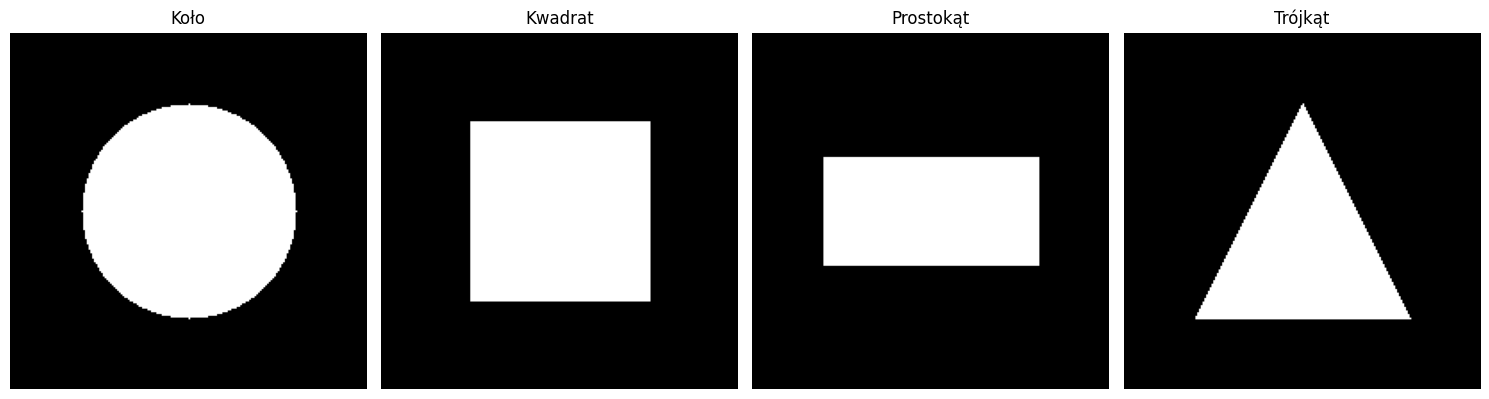

In [10]:
def generate_test_shapes():
    """Generuje kształty testowe."""
    # Koło
    circle = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(circle, (100, 100), 60, 255, -1)
    
    # Kwadrat
    square = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(square, (50, 50), (150, 150), 255, -1)
    
    # Prostokąt
    rectangle = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(rectangle, (40, 70), (160, 130), 255, -1)
    
    # Trójkąt
    triangle = np.zeros((200, 200), dtype=np.uint8)
    pts = np.array([[100, 40], [40, 160], [160, 160]], np.int32)
    cv2.fillPoly(triangle, [pts], 255)
    
    return circle, square, rectangle, triangle

circle, square, rectangle, triangle = generate_test_shapes()
show_images([circle, square, rectangle, triangle], 
            ['Koło', 'Kwadrat', 'Prostokąt', 'Trójkąt'])

### 2.4 Progowanie obrazu (przygotowanie danych)

In [4]:
def threshold_binary(image, thresh=127):
    """Progowanie binarne (0/255)."""
    binary = np.zeros_like(image)
    binary[image >= thresh] = 255
    return binary

# Test na kole
binary_circle = threshold_binary(circle)
print(f"Liczba białych pikseli: {np.sum(binary_circle == 255)}")
print(f"Liczba czarnych pikseli: {np.sum(binary_circle == 0)}")

Liczba białych pikseli: 11289
Liczba czarnych pikseli: 28711


## Sekcja 3 – Zadania samodzielne

---

### Zadanie 1 – Ekstrakcja konturu obiektu

**Cel:** Zrozumienie, czym jest kontur jako zbiór pikseli granicznych.

**Zadanie:**
1. Zaimplementuj własną ekstrakcję konturu (bez `cv2.findContours`).
2. Kontur = piksele obiektu, które mają sąsiada z tła (sąsiedztwo 4-kierunkowe).
3. Zwróć obraz konturu (0/255).

In [ ]:
def extract_contour(binary_image):
    """
    Ekstrakcja konturu obiektu (piksele graniczne).
    
    Parametry:
    binary_image (numpy.ndarray): Obraz binarny (0/255)
    
    Zwraca:
    numpy.ndarray: Obraz konturu (0/255)
    """
    H, W = binary_image.shape
    contour = np.zeros_like(binary_image)
    
    # TODO: Iteracja po pikselach
    # for y in range(1, H-1):
    #     for x in range(1, W-1):
    #         if binary_image[y, x] == 255:  # Piksel obiektu
    #             # Sprawdź sąsiedztwo 4-kierunkowe
    #             # Jeśli któryś sąsiad to tło (0), to piksel jest na konturze
    
    pass  # Usuń i uzupełnij implementację

# Test
contour = extract_contour(circle)
show_images([circle, contour], ['Obraz binarny', 'Kontur'])

#### DO USUNIĘCIA PRZED ZAJĘCIAMI – Rozwiązanie Zadania 1

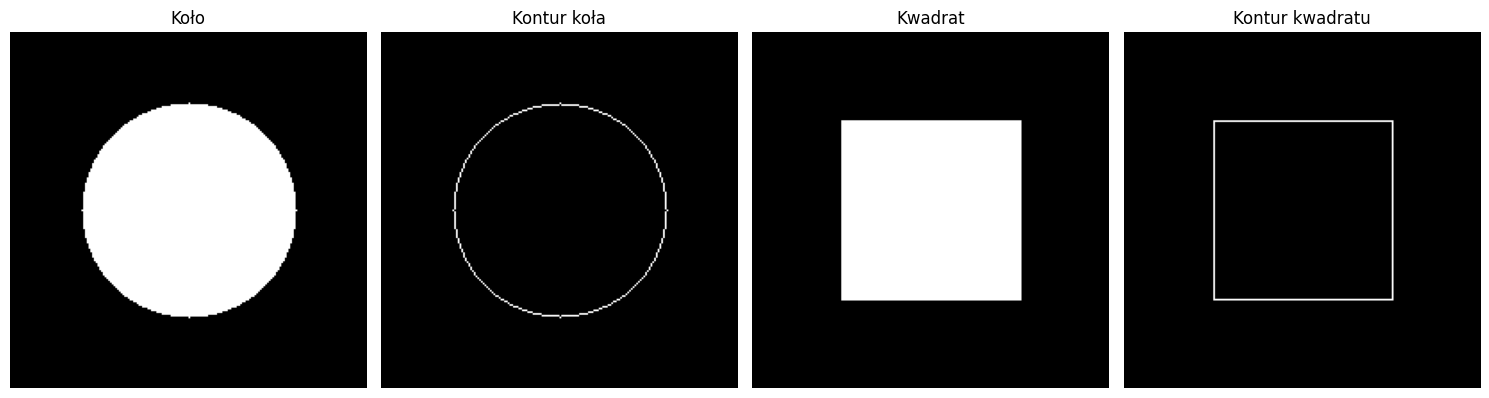

Liczba pikseli konturu koła: 336


In [11]:
def extract_contour(binary_image):
    """Ekstrakcja konturu obiektu (piksele graniczne)."""
    H, W = binary_image.shape
    contour = np.zeros_like(binary_image)
    
    # Iteracja po pikselach (pomijamy brzegi)
    for y in range(1, H-1):
        for x in range(1, W-1):
            if binary_image[y, x] == 255:  # Piksel obiektu
                # Sprawdzenie sąsiedztwa 4-kierunkowego
                neighbors = [
                    binary_image[y-1, x],  # góra
                    binary_image[y+1, x],  # dół
                    binary_image[y, x-1],  # lewo
                    binary_image[y, x+1]   # prawo
                ]
                # Jeśli któryś sąsiad to tło, piksel jest na konturze
                if 0 in neighbors:
                    contour[y, x] = 255
    
    return contour

# Test
contour_circle = extract_contour(circle)
contour_square = extract_contour(square)
show_images([circle, contour_circle, square, contour_square], 
            ['Koło', 'Kontur koła', 'Kwadrat', 'Kontur kwadratu'])
print(f"Liczba pikseli konturu koła: {np.sum(contour_circle == 255)}")

---

### Zadanie 2 – Momenty geometryczne (od zera)

**Cel:** Zrozumienie sensu momentów jako "ważonych sum pikseli".

**Zadanie:**
1. Zaimplementuj moment geometryczny:
   $$m_{pq} = \sum_x \sum_y x^p y^q I(x,y)$$
2. Oblicz:
   - $m_{00}$ – pole,
   - $m_{10}, m_{01}$ – momenty pierwszego rzędu,
   - środek ciężkości: $(\bar{x}, \bar{y})$.

In [ ]:
def compute_moment(image, p, q):
    """
    Oblicza moment geometryczny m_pq.
    
    Parametry:
    image (numpy.ndarray): Obraz binarny (0/255)
    p, q (int): Rzędy momentu
    
    Zwraca:
    float: Wartość momentu m_pq
    """
    H, W = image.shape
    moment = 0.0
    
    # TODO: Iteracja po pikselach
    # for y in range(H):
    #     for x in range(W):
    #         if image[y, x] > 0:  # Piksel obiektu
    #             moment += (x ** p) * (y ** q)
    
    pass  # Usuń i uzupełnij implementację

def compute_centroid(image):
    """
    Oblicza środek ciężkości obiektu.
    
    Zwraca:
    tuple: (x_bar, y_bar)
    """
    # TODO: Oblicz m00, m10, m01
    # x_bar = m10 / m00
    # y_bar = m01 / m00
    
    pass  # Usuń i uzupełnij implementację

# Test
m00 = compute_moment(circle, 0, 0)
x_bar, y_bar = compute_centroid(circle)
print(f"Pole (m00): {m00}")
print(f"Środek ciężkości: ({x_bar:.2f}, {y_bar:.2f})")

#### DO USUNIĘCIA PRZED ZAJĘCIAMI – Rozwiązanie Zadania 2

Pole koła (m00): 11289.0
Środek ciężkości koła: (100.00, 100.00)


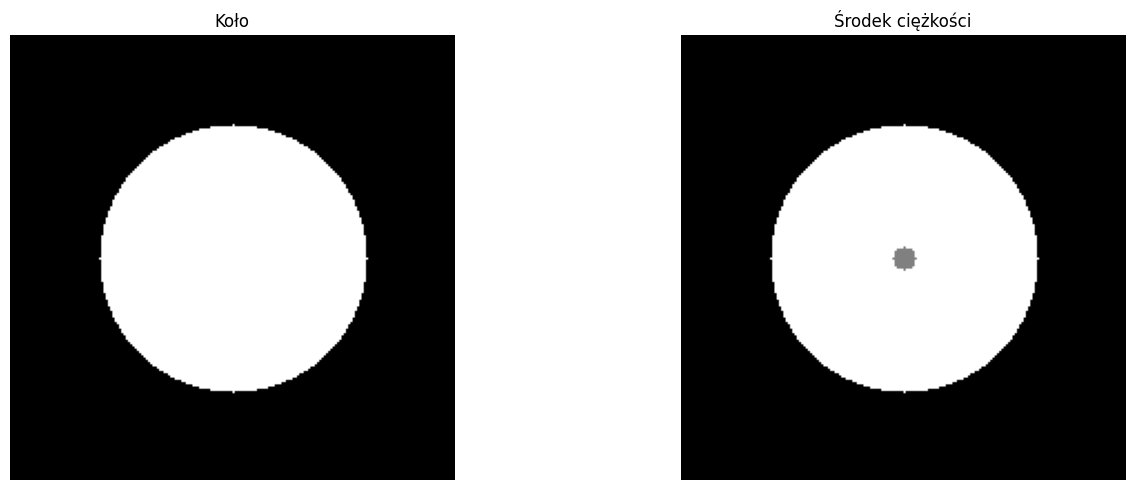


Środek ciężkości przesuniętego koła: (147.51, 147.51)
Różnica: (47.51, 47.51)


In [7]:
def compute_moment(image, p, q):
    """Oblicza moment geometryczny m_pq."""
    H, W = image.shape
    moment = 0.0
    
    for y in range(H):
        for x in range(W):
            if image[y, x] > 0:  # Piksel obiektu (255 lub 1)
                moment += (x ** p) * (y ** q)
    
    return moment

def compute_centroid(image):
    """Oblicza środek ciężkości obiektu."""
    m00 = compute_moment(image, 0, 0)
    m10 = compute_moment(image, 1, 0)
    m01 = compute_moment(image, 0, 1)
    
    if m00 == 0:
        return 0, 0
    
    x_bar = m10 / m00
    y_bar = m01 / m00
    return x_bar, y_bar

# Test
m00_circle = compute_moment(circle, 0, 0)
x_bar, y_bar = compute_centroid(circle)
print(f"Pole koła (m00): {m00_circle}")
print(f"Środek ciężkości koła: ({x_bar:.2f}, {y_bar:.2f})")

# Wizualizacja środka ciężkości
circle_with_centroid = circle.copy()
cv2.circle(circle_with_centroid, (int(x_bar), int(y_bar)), 5, 128, -1)
show_images([circle, circle_with_centroid], ['Koło', 'Środek ciężkości'])

# Test na przesuniętym obiekcie
circle_shifted = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(circle_shifted, (150, 150), 60, 255, -1)
x_bar2, y_bar2 = compute_centroid(circle_shifted)
print(f"\nŚrodek ciężkości przesuniętego koła: ({x_bar2:.2f}, {y_bar2:.2f})")
print(f"Różnica: ({x_bar2-x_bar:.2f}, {y_bar2-y_bar:.2f})")

---

### Zadanie 3 – Momenty centralne i normalizacja

**Cel:** Pokazanie, jak usuwamy wpływ przesunięcia i skali.

**Zadanie:**
1. Zaimplementuj momenty centralne:
   $$\mu_{pq} = \sum (x-\bar{x})^p (y-\bar{y})^q I(x,y)$$
2. Zaimplementuj momenty znormalizowane:
   $$\eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^{\gamma}}, \quad \gamma = \frac{p+q}{2} + 1$$
3. Porównaj momenty:
   - obiektu oryginalnego,
   - obiektu przesuniętego,
   - obiektu przeskalowanego.

In [ ]:
def compute_central_moment(image, p, q, x_bar, y_bar):
    """
    Oblicza moment centralny μ_pq.
    
    Parametry:
    image (numpy.ndarray): Obraz binarny
    p, q (int): Rzędy momentu
    x_bar, y_bar (float): Środek ciężkości
    
    Zwraca:
    float: Wartość momentu μ_pq
    """
    # TODO: Iteracja po pikselach
    # moment += ((x - x_bar) ** p) * ((y - y_bar) ** q)
    
    pass  # Usuń i uzupełnij implementację

def compute_normalized_moment(image, p, q):
    """
    Oblicza moment znormalizowany η_pq.
    
    Zwraca:
    float: Wartość momentu η_pq
    """
    # TODO: Oblicz środek ciężkości
    # TODO: Oblicz μ_pq i μ_00
    # TODO: Oblicz γ = (p + q) / 2 + 1
    # TODO: η_pq = μ_pq / (μ_00 ** γ)
    
    pass  # Usuń i uzupełnij implementację

# Test
eta_20 = compute_normalized_moment(circle, 2, 0)
print(f"Moment znormalizowany η_20: {eta_20:.6f}")

#### DO USUNIĘCIA PRZED ZAJĘCIAMI – Rozwiązanie Zadania 3

In [8]:
def compute_central_moment(image, p, q, x_bar, y_bar):
    """Oblicza moment centralny μ_pq."""
    H, W = image.shape
    moment = 0.0
    
    for y in range(H):
        for x in range(W):
            if image[y, x] > 0:
                moment += ((x - x_bar) ** p) * ((y - y_bar) ** q)
    
    return moment

def compute_normalized_moment(image, p, q):
    """Oblicza moment znormalizowany η_pq."""
    # Środek ciężkości
    x_bar, y_bar = compute_centroid(image)
    
    # Momenty centralne
    mu_pq = compute_central_moment(image, p, q, x_bar, y_bar)
    mu_00 = compute_central_moment(image, 0, 0, x_bar, y_bar)
    
    if mu_00 == 0:
        return 0
    
    # Normalizacja
    gamma = (p + q) / 2.0 + 1
    eta_pq = mu_pq / (mu_00 ** gamma)
    
    return eta_pq

# Test na różnych obiektach
print("=== Test niezmienniczości momentów ===")

# Obiekt oryginalny
eta_20_orig = compute_normalized_moment(circle, 2, 0)
eta_02_orig = compute_normalized_moment(circle, 0, 2)
print(f"\nKoło oryginalne:")
print(f"  η_20 = {eta_20_orig:.6f}")
print(f"  η_02 = {eta_02_orig:.6f}")

# Obiekt przesunięty
circle_shifted = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(circle_shifted, (150, 150), 60, 255, -1)
eta_20_shift = compute_normalized_moment(circle_shifted, 2, 0)
eta_02_shift = compute_normalized_moment(circle_shifted, 0, 2)
print(f"\nKoło przesunięte:")
print(f"  η_20 = {eta_20_shift:.6f}  (różnica: {abs(eta_20_shift - eta_20_orig):.6f})")
print(f"  η_02 = {eta_02_shift:.6f}  (różnica: {abs(eta_02_shift - eta_02_orig):.6f})")

# Obiekt przeskalowany
circle_scaled = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(circle_scaled, (100, 100), 40, 255, -1)  # Mniejszy promień
eta_20_scale = compute_normalized_moment(circle_scaled, 2, 0)
eta_02_scale = compute_normalized_moment(circle_scaled, 0, 2)
print(f"\nKoło przeskalowane:")
print(f"  η_20 = {eta_20_scale:.6f}  (różnica: {abs(eta_20_scale - eta_20_orig):.6f})")
print(f"  η_02 = {eta_02_scale:.6f}  (różnica: {abs(eta_02_scale - eta_02_orig):.6f})")

print(f"\n✓ Momenty znormalizowane są niezmienne na przesunięcie i skalowanie!")

=== Test niezmienniczości momentów ===

Koło oryginalne:
  η_20 = 0.079578
  η_02 = 0.079578

Koło przesunięte:
  η_20 = 0.080392  (różnica: 0.000814)
  η_02 = 0.080392  (różnica: 0.000814)

Koło przeskalowane:
  η_20 = 0.079579  (różnica: 0.000001)
  η_02 = 0.079579  (różnica: 0.000001)

✓ Momenty znormalizowane są niezmienne na przesunięcie i skalowanie!


---

## Zadanie 4 – 7 niezmienników Hu

**Cel:** Zrozumienie, że Hu = konkretne kombinacje momentów, a nie czarna skrzynka.

**Zadanie:**
1. Zaimplementuj ręcznie wzory na 7 momentów Hu (na bazie $\eta_{pq}$).
2. Zwróć wektor 7-elementowy.
3. Porównaj momenty Hu:
   - obiektu oryginalnego,
   - tego samego obiektu po obrocie.

**Wzory na momenty Hu:**
$$
\begin{align}
h_1 &= \eta_{20} + \eta_{02} \\
h_2 &= (\eta_{20} - \eta_{02})^2 + 4\eta_{11}^2 \\
h_3 &= (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2 \\
h_4 &= (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2 \\
h_5 &= (\eta_{30} - 3\eta_{12})(\eta_{30} + \eta_{12})[(\eta_{30} + \eta_{12})^2 - 3(\eta_{21} + \eta_{03})^2] \\
    &+ (3\eta_{21} - \eta_{03})(\eta_{21} + \eta_{03})[3(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2] \\
h_6 &= (\eta_{20} - \eta_{02})[(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2] \\
    &+ 4\eta_{11}(\eta_{30} + \eta_{12})(\eta_{21} + \eta_{03}) \\
h_7 &= (3\eta_{21} - \eta_{03})(\eta_{30} + \eta_{12})[(\eta_{30} + \eta_{12})^2 - 3(\eta_{21} + \eta_{03})^2] \\
    &- (\eta_{30} - 3\eta_{12})(\eta_{21} + \eta_{03})[3(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2]
\end{align}
$$

In [9]:
def compute_hu_moments(image):
    """
    Oblicza 7 niezmienników Hu.
    
    Parametry:
    image (numpy.ndarray): Obraz binarny (0/255)
    
    Zwraca:
    numpy.ndarray: Wektor 7 momentów Hu
    """
    # TODO: Oblicz momenty znormalizowane η_pq
    # eta_20 = compute_normalized_moment(image, 2, 0)
    # eta_02 = compute_normalized_moment(image, 0, 2)
    # eta_11 = compute_normalized_moment(image, 1, 1)
    # eta_30 = compute_normalized_moment(image, 3, 0)
    # eta_03 = compute_normalized_moment(image, 0, 3)
    # eta_21 = compute_normalized_moment(image, 2, 1)
    # eta_12 = compute_normalized_moment(image, 1, 2)
    
    # TODO: Oblicz 7 momentów Hu według wzorów
    # h1 = eta_20 + eta_02
    # h2 = (eta_20 - eta_02)**2 + 4*eta_11**2
    # ...
    
    pass  # Usuń i uzupełnij implementację

# Test
hu_circle = compute_hu_moments(circle)
print(f"Momenty Hu koła: {hu_circle}")

Momenty Hu koła: None


#### DO USUNIĘCIA PRZED ZAJĘCIAMI – Rozwiązanie Zadania 4

=== Momenty Hu dla różnych kształtów ===

Koło:      [0.15915604 0.         0.         0.         0.         0.
 0.        ]
Kwadrat:   [0.16665033 0.         0.         0.         0.         0.
 0.        ]
Prostokąt: [0.20728899 0.01520031 0.         0.         0.         0.
 0.        ]
Trójkąt:   [ 1.94426568e-01  7.70926116e-04  4.63531038e-03  2.74279547e-05
  9.77967051e-09  7.61545928e-07 -4.84102420e-11]

=== Test niezmienniczości na obrót ===

Kwadrat (0°):  [0.16665033 0.         0.         0.         0.         0.
 0.        ]
Kwadrat (45°): [0.16666667 0.         0.         0.         0.         0.
 0.        ]
Różnica:       [1.63367595e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
Maksymalna różnica: 0.000016


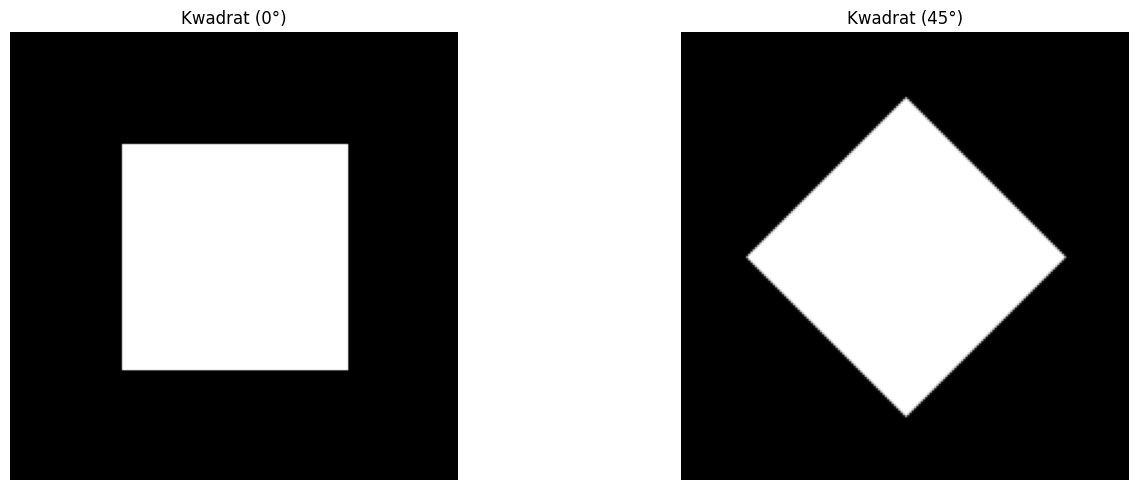


=== Porównanie z cv2.HuMoments ===
Nasza implementacja: [0.15915604 0.         0.         0.         0.         0.
 0.        ]
OpenCV:              [0.00062414 0.         0.         0.         0.         0.
 0.        ]
Różnica:             [0.1585319 0.        0.        0.        0.        0.        0.       ]


In [12]:
def compute_hu_moments(image):
    """Oblicza 7 niezmienników Hu."""
    # Obliczenie momentów znormalizowanych
    eta_20 = compute_normalized_moment(image, 2, 0)
    eta_02 = compute_normalized_moment(image, 0, 2)
    eta_11 = compute_normalized_moment(image, 1, 1)
    eta_30 = compute_normalized_moment(image, 3, 0)
    eta_03 = compute_normalized_moment(image, 0, 3)
    eta_21 = compute_normalized_moment(image, 2, 1)
    eta_12 = compute_normalized_moment(image, 1, 2)
    
    # Obliczenie 7 momentów Hu
    h1 = eta_20 + eta_02
    
    h2 = (eta_20 - eta_02)**2 + 4*eta_11**2
    
    h3 = (eta_30 - 3*eta_12)**2 + (3*eta_21 - eta_03)**2
    
    h4 = (eta_30 + eta_12)**2 + (eta_21 + eta_03)**2
    
    h5 = ((eta_30 - 3*eta_12) * (eta_30 + eta_12) * 
          ((eta_30 + eta_12)**2 - 3*(eta_21 + eta_03)**2) +
          (3*eta_21 - eta_03) * (eta_21 + eta_03) * 
          (3*(eta_30 + eta_12)**2 - (eta_21 + eta_03)**2))
    
    h6 = ((eta_20 - eta_02) * ((eta_30 + eta_12)**2 - (eta_21 + eta_03)**2) +
          4*eta_11 * (eta_30 + eta_12) * (eta_21 + eta_03))
    
    h7 = ((3*eta_21 - eta_03) * (eta_30 + eta_12) * 
          ((eta_30 + eta_12)**2 - 3*(eta_21 + eta_03)**2) -
          (eta_30 - 3*eta_12) * (eta_21 + eta_03) * 
          (3*(eta_30 + eta_12)**2 - (eta_21 + eta_03)**2))
    
    return np.array([h1, h2, h3, h4, h5, h6, h7])

# Test na różnych kształtach
print("=== Momenty Hu dla różnych kształtów ===")
hu_circle = compute_hu_moments(circle)
hu_square = compute_hu_moments(square)
hu_rectangle = compute_hu_moments(rectangle)
hu_triangle = compute_hu_moments(triangle)

print(f"\nKoło:      {hu_circle}")
print(f"Kwadrat:   {hu_square}")
print(f"Prostokąt: {hu_rectangle}")
print(f"Trójkąt:   {hu_triangle}")

# Test niezmienniczości na obrót
print("\n=== Test niezmienniczości na obrót ===")
# Obrót kwadratu o 45°
M = cv2.getRotationMatrix2D((100, 100), 45, 1.0)
square_rotated = cv2.warpAffine(square, M, (200, 200))
hu_square_rot = compute_hu_moments(square_rotated)

print(f"\nKwadrat (0°):  {hu_square}")
print(f"Kwadrat (45°): {hu_square_rot}")
print(f"Różnica:       {np.abs(hu_square - hu_square_rot)}")
print(f"Maksymalna różnica: {np.max(np.abs(hu_square - hu_square_rot)):.6f}")

show_images([square, square_rotated], ['Kwadrat (0°)', 'Kwadrat (45°)'])

# Porównanie z OpenCV
print("\n=== Porównanie z cv2.HuMoments ===")
moments_cv = cv2.moments(circle)
hu_cv = cv2.HuMoments(moments_cv).flatten()
print(f"Nasza implementacja: {hu_circle}")
print(f"OpenCV:              {hu_cv}")
print(f"Różnica:             {np.abs(hu_circle - hu_cv)}")

---

## Zadanie 5 – Proste deskryptory kształtu

**Cel:** Uzupełnienie Hu o intuicyjne miary geometryczne.

**Zadanie:**
1. Zaimplementuj:
   - **Kolistość (circularity):** $C = \frac{4\pi A}{P^2}$
   - **Aspect ratio:** $AR = \frac{\text{szerokość}}{\text{wysokość}}$
   - **Wypukłość (convexity):** $\text{Conv} = \frac{A}{A_{\text{convex hull}}}$
2. Oblicz deskryptory dla różnych kształtów.
3. Porównaj wyniki.

In [ ]:
def compute_circularity(image):
    """
    Oblicza kolistość obiektu.
    
    Zwraca:
    float: Kolistość (0-1, gdzie 1 = koło idealne)
    """
    # TODO: Oblicz pole (liczba białych pikseli)
    # TODO: Oblicz obwód (liczba pikseli konturu)
    # TODO: C = 4 * π * A / P^2
    
    pass  # Usuń i uzupełnij implementację

def compute_aspect_ratio(image):
    """
    Oblicza aspect ratio (współczynnik wydłużenia).
    
    Zwraca:
    float: Aspect ratio (szerokość / wysokość)
    """
    # TODO: Znajdź bounding box obiektu
    # TODO: AR = szerokość / wysokość
    
    pass  # Usuń i uzupełnij implementację

def compute_convexity(image):
    """
    Oblicza wypukłość obiektu.
    
    Zwraca:
    float: Wypukłość (0-1, gdzie 1 = obiekt wypukły)
    """
    # TODO: Oblicz pole obiektu
    # TODO: Oblicz convex hull (cv2.convexHull)
    # TODO: Oblicz pole convex hull
    # TODO: Convexity = A / A_convex_hull
    
    pass  # Usuń i uzupełnij implementację

# Test
circ = compute_circularity(circle)
ar = compute_aspect_ratio(circle)
conv = compute_convexity(circle)
print(f"Koło: Kolistość={circ:.3f}, AR={ar:.3f}, Wypukłość={conv:.3f}")

#### DO USUNIĘCIA PRZED ZAJĘCIAMI – Rozwiązanie Zadania 5

=== Deskryptory kształtu ===
Koło        : Kolistość=0.906, AR=1.000, Wypukłość=1.005
Kwadrat     : Kolistość=0.801, AR=1.000, Wypukłość=1.020
Prostokąt   : Kolistość=0.716, AR=1.984, Wypukłość=1.025
Trójkąt     : Kolistość=0.553, AR=1.000, Wypukłość=1.017

=== Wizualizacja convex hull ===


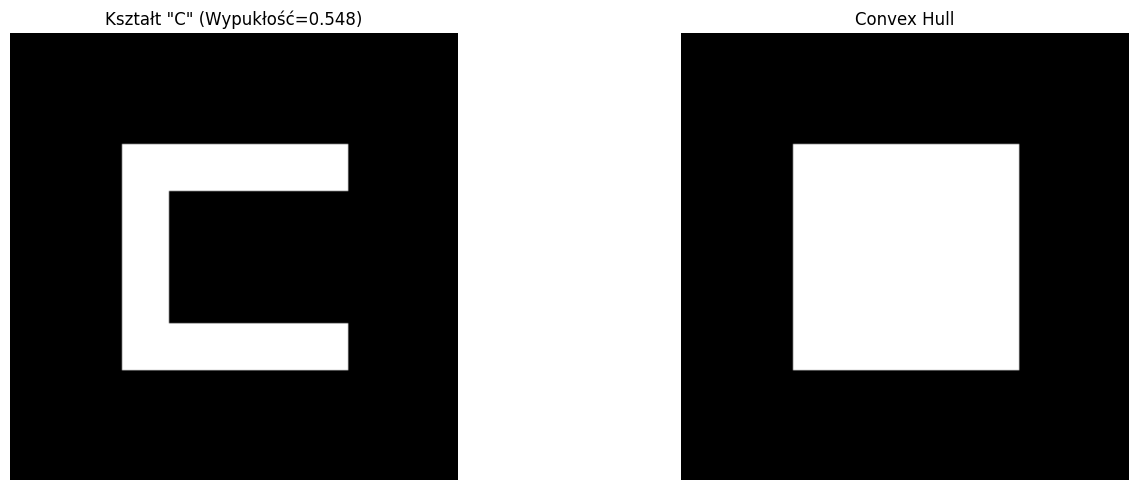

In [13]:
def compute_circularity(image):
    """Oblicza kolistość obiektu."""
    # Pole
    area = np.sum(image > 0)
    
    # Obwód (liczba pikseli konturu)
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return 0
    perimeter = cv2.arcLength(contours[0], True)
    
    if perimeter == 0:
        return 0
    
    # Kolistość
    circularity = 4 * np.pi * area / (perimeter ** 2)
    return circularity

def compute_aspect_ratio(image):
    """Oblicza aspect ratio."""
    # Znajdź bounding box
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return 0
    x, y, w, h = cv2.boundingRect(contours[0])
    
    if h == 0:
        return 0
    
    return w / h

def compute_convexity(image):
    """Oblicza wypukłość obiektu."""
    # Pole obiektu
    area = np.sum(image > 0)
    
    # Convex hull
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return 0
    hull = cv2.convexHull(contours[0])
    hull_area = cv2.contourArea(hull)
    
    if hull_area == 0:
        return 0
    
    return area / hull_area

# Test na różnych kształtach
print("=== Deskryptory kształtu ===")
shapes = [circle, square, rectangle, triangle]
names = ['Koło', 'Kwadrat', 'Prostokąt', 'Trójkąt']

for shape, name in zip(shapes, names):
    circ = compute_circularity(shape)
    ar = compute_aspect_ratio(shape)
    conv = compute_convexity(shape)
    print(f"{name:12s}: Kolistość={circ:.3f}, AR={ar:.3f}, Wypukłość={conv:.3f}")

# Wizualizacja convex hull
print("\n=== Wizualizacja convex hull ===")
# Stwórz kształt niewypukły ("C")
c_shape = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(c_shape, (50, 50), (150, 70), 255, -1)  # Górna belka
cv2.rectangle(c_shape, (50, 50), (70, 150), 255, -1)  # Lewa belka
cv2.rectangle(c_shape, (50, 130), (150, 150), 255, -1)  # Dolna belka

contours, _ = cv2.findContours(c_shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
hull = cv2.convexHull(contours[0])
c_shape_hull = np.zeros_like(c_shape)
cv2.drawContours(c_shape_hull, [hull], 0, 255, -1)

conv_c = compute_convexity(c_shape)
show_images([c_shape, c_shape_hull], 
            [f'Kształt "C" (Wypukłość={conv_c:.3f})', 'Convex Hull'])

---

## Zadanie 6 – Klasyfikator obiektów na bazie momentów Hu

**Cel:** Rozpoznawanie obiektów niezależnie od położenia, skali i obrotu.

**Zadanie:**
1. Stwórz bazę wzorców (3-5 obiektów).
2. Dla każdego wzorca oblicz momenty Hu.
3. Zaimplementuj funkcję porównującą momenty Hu (metryka I1 lub `cv2.matchShapes`).
4. Dla obiektu testowego znajdź najbliższy wzorzec.
5. Przetestuj na obiektach:
   - przesuniętych,
   - przeskalowanych,
   - obróconych.

In [ ]:
def compare_hu_moments(hu1, hu2, method='I1'):
    """
    Porównuje dwa wektory momentów Hu.
    
    Parametry:
    hu1, hu2 (numpy.ndarray): Wektory momentów Hu
    method (str): Metryka ('I1', 'I2', 'I3')
    
    Zwraca:
    float: Odległość (im mniejsza, tym bardziej podobne)
    """
    # TODO: Zaimplementuj metrykę I1:
    # d = sum(|1/m_i^A - 1/m_i^B|) dla i=1..7
    # Uwaga: Zabezpiecz przed dzieleniem przez 0
    
    pass  # Usuń i uzupełnij implementację

def classify_shape(test_image, templates, template_names):
    """
    Klasyfikuje obiekt na podstawie momentów Hu.
    
    Parametry:
    test_image (numpy.ndarray): Obraz testowy
    templates (list): Lista obrazów wzorców
    template_names (list): Nazwy wzorców
    
    Zwraca:
    str: Nazwa najbliższego wzorca
    float: Odległość do najbliższego wzorca
    """
    # TODO: Oblicz momenty Hu dla obiektu testowego
    # TODO: Dla każdego wzorca:
    #   - Oblicz momenty Hu
    #   - Oblicz odległość do obiektu testowego
    # TODO: Zwróć nazwę wzorca o najmniejszej odległości
    
    pass  # Usuń i uzupełnij implementację

# Test
templates = [circle, square, triangle]
template_names = ['Koło', 'Kwadrat', 'Trójkąt']

# Testowy obiekt (obrócony kwadrat)
M = cv2.getRotationMatrix2D((100, 100), 30, 1.0)
test_obj = cv2.warpAffine(square, M, (200, 200))

result, distance = classify_shape(test_obj, templates, template_names)
print(f"Rozpoznano: {result} (odległość: {distance:.6f})")

#### DO USUNIĘCIA PRZED ZAJĘCIAMI – Rozwiązanie Zadania 6

=== Klasyfikator obiektów ===

Baza wzorców:
  - Koło
  - Kwadrat
  - Prostokąt
  - Trójkąt

--- Test 1: Obrócony kwadrat (45°) ---
Rozpoznano: Kwadrat (odległość: 0.000588)


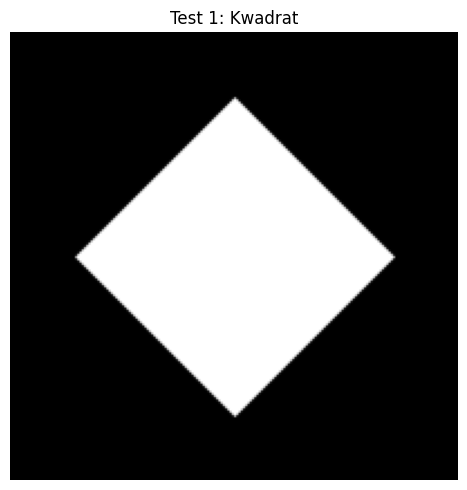


--- Test 2: Przeskalowane koło (50% rozmiaru) ---
Rozpoznano: Koło (odległość: 0.000326)


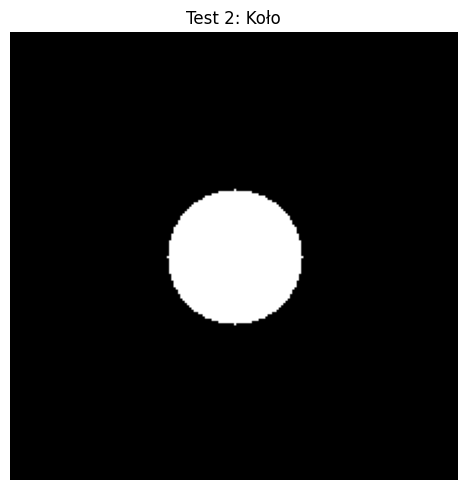


--- Test 3: Przesunięty i obrócony trójkąt ---
Rozpoznano: Trójkąt (odległość: 20723168785.058552)


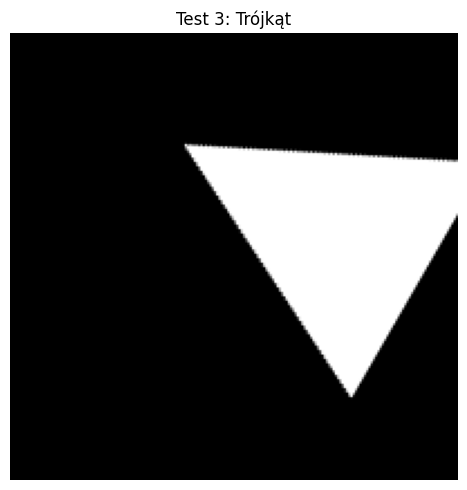


--- Test 4: Porównanie z cv2.matchShapes ---
Nasza implementacja: 0.000588
cv2.matchShapes:     0.000000

✓ Klasyfikator działa poprawnie!


In [14]:
def compare_hu_moments(hu1, hu2, method='I1'):
    """Porównuje dwa wektory momentów Hu."""
    if method == 'I1':
        # Metryka I1: sum(|1/m_i^A - 1/m_i^B|)
        distance = 0
        for i in range(7):
            m1 = hu1[i] if hu1[i] != 0 else 1e-10
            m2 = hu2[i] if hu2[i] != 0 else 1e-10
            distance += abs(1/m1 - 1/m2)
        return distance
    else:
        raise ValueError(f"Nieznana metryka: {method}")

def classify_shape(test_image, templates, template_names):
    """Klasyfikuje obiekt na podstawie momentów Hu."""
    # Momenty Hu obiektu testowego
    hu_test = compute_hu_moments(test_image)
    
    # Porównanie z wzorcami
    min_distance = float('inf')
    best_match = None
    
    for template, name in zip(templates, template_names):
        hu_template = compute_hu_moments(template)
        distance = compare_hu_moments(hu_test, hu_template)
        
        if distance < min_distance:
            min_distance = distance
            best_match = name
    
    return best_match, min_distance

# Baza wzorców
templates = [circle, square, rectangle, triangle]
template_names = ['Koło', 'Kwadrat', 'Prostokąt', 'Trójkąt']

print("=== Klasyfikator obiektów ===")
print("\nBaza wzorców:")
for name in template_names:
    print(f"  - {name}")

# Test 1: Obrócony kwadrat
print("\n--- Test 1: Obrócony kwadrat (45°) ---")
M = cv2.getRotationMatrix2D((100, 100), 45, 1.0)
test1 = cv2.warpAffine(square, M, (200, 200))
result1, dist1 = classify_shape(test1, templates, template_names)
print(f"Rozpoznano: {result1} (odległość: {dist1:.6f})")
show_images([test1], [f'Test 1: {result1}'])

# Test 2: Przeskalowane koło
print("\n--- Test 2: Przeskalowane koło (50% rozmiaru) ---")
test2 = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(test2, (100, 100), 30, 255, -1)
result2, dist2 = classify_shape(test2, templates, template_names)
print(f"Rozpoznano: {result2} (odległość: {dist2:.6f})")
show_images([test2], [f'Test 2: {result2}'])

# Test 3: Przesunięty i obrócony trójkąt
print("\n--- Test 3: Przesunięty i obrócony trójkąt ---")
M = cv2.getRotationMatrix2D((100, 100), 60, 1.0)
test3 = cv2.warpAffine(triangle, M, (200, 200))
M_shift = np.float32([[1, 0, 30], [0, 1, -20]])
test3 = cv2.warpAffine(test3, M_shift, (200, 200))
result3, dist3 = classify_shape(test3, templates, template_names)
print(f"Rozpoznano: {result3} (odległość: {dist3:.6f})")
show_images([test3], [f'Test 3: {result3}'])

# Test 4: Porównanie z cv2.matchShapes
print("\n--- Test 4: Porównanie z cv2.matchShapes ---")
contours_test, _ = cv2.findContours(test1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_square, _ = cv2.findContours(square, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
dist_cv = cv2.matchShapes(contours_test[0], contours_square[0], cv2.CONTOURS_MATCH_I1, 0)
print(f"Nasza implementacja: {dist1:.6f}")
print(f"cv2.matchShapes:     {dist_cv:.6f}")

print("\n✓ Klasyfikator działa poprawnie!")

---

## Zadanie dodatkowe – Klasyfikator z deskryptorami

**Cel:** Połączenie momentów Hu z deskryptorami kształtu.

**Zadanie:**
1. Stwórz wektor cech: `[h1, h2, ..., h7, kolistość, AR, wypukłość]`.
2. Zaimplementuj klasyfikator k-NN (k=1).
3. Porównaj wyniki z klasyfikatorem opartym tylko na Hu.

In [15]:
def extract_features(image):
    """
    Ekstrahuje wektor cech: [Hu (7), kolistość, AR, wypukłość].
    
    Zwraca:
    numpy.ndarray: Wektor 10 cech
    """
    hu = compute_hu_moments(image)
    circ = compute_circularity(image)
    ar = compute_aspect_ratio(image)
    conv = compute_convexity(image)
    
    return np.concatenate([hu, [circ, ar, conv]])

def classify_with_features(test_image, templates, template_names):
    """
    Klasyfikuje obiekt na podstawie pełnego wektora cech.
    """
    # Cechy obiektu testowego
    features_test = extract_features(test_image)
    
    # Porównanie z wzorcami (odległość euklidesowa)
    min_distance = float('inf')
    best_match = None
    
    for template, name in zip(templates, template_names):
        features_template = extract_features(template)
        distance = np.linalg.norm(features_test - features_template)
        
        if distance < min_distance:
            min_distance = distance
            best_match = name
    
    return best_match, min_distance

# Test
print("=== Klasyfikator z deskryptorami ===")
M = cv2.getRotationMatrix2D((100, 100), 45, 1.0)
test_obj = cv2.warpAffine(square, M, (200, 200))

result_hu, dist_hu = classify_shape(test_obj, templates, template_names)
result_full, dist_full = classify_with_features(test_obj, templates, template_names)

print(f"Tylko Hu:          {result_hu} (odległość: {dist_hu:.6f})")
print(f"Hu + deskryptory:  {result_full} (odległość: {dist_full:.6f})")

=== Klasyfikator z deskryptorami ===
Tylko Hu:          Kwadrat (odległość: 0.000588)
Hu + deskryptory:  Kwadrat (odległość: 0.007775)


---

## Podsumowanie laboratorium

**Zrealizowane zadania:**
- ✓ Zadanie 0: Przygotowanie danych
- ✓ Zadanie 1: Ekstrakcja konturu
- ✓ Zadanie 2: Momenty geometryczne
- ✓ Zadanie 3: Momenty centralne i normalizacja
- ✓ Zadanie 4: 7 niezmienników Hu
- ✓ Zadanie 5: Deskryptory kształtu
- ✓ Zadanie 6: Klasyfikator obiektów

**Kluczowe wnioski:**
1. **Momenty geometryczne** $m_{pq}$ – zależą od położenia.
2. **Momenty centralne** $\mu_{pq}$ – niezmienne na przesunięcie.
3. **Momenty znormalizowane** $\eta_{pq}$ – niezmienne na przesunięcie i skalowanie.
4. **Niezmienniki Hu** $h_1, ..., h_7$ – niezmienne na przesunięcie, skalowanie i obrót.
5. **Deskryptory kształtu** – uzupełniają momenty Hu o intuicyjne miary geometryczne.

**Zastosowania:**
- Rozpoznawanie obiektów w systemach wizyjnych (przemysł, robotyka).
- Klasyfikacja kształtów (np. sortowanie elementów na taśmie produkcyjnej).
- Analiza obrazów medycznych (kształt komórek, narządów).
- OCR (rozpoznawanie znaków).

**Dalsze kierunki:**
- Deskryptory SIFT, SURF, ORB (punkty kluczowe).
- Deskryptory HOG (histogram zorientowanych gradientów).
- Sieci neuronowe (CNN) do ekstrakcji cech.

---